# Group 7 - Fake News Detection
## Text Analytics Group Project

**Group Members:
Meng Zhang -22424168
Jubrighter Maame Frimp-22420884
Adwoa Serwah Kyei-Baff-22419517
Enock sayibu-22419566
Francisca Dede Teye Wo-22422969

**Task:** Fake News Detection using BERT Embeddings

**Models:** Logistic Regression + SVM

**Evaluation Metrics:** Accuracy, Precision, Recall, F1-Score, Confusion Matrix, ROC-AUC

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score
)
from sklearn.preprocessing import StandardScaler

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import torch
from sentence_transformers import SentenceTransformer

import joblib
from tqdm import tqdm

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

All libraries imported successfully!
PyTorch version: 2.13.0+cpu
CUDA available: False


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ZHANGMENG\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ZHANGMENG\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 2. Load and Inspect Dataset

In [2]:
# Load the datasets
fake_df = pd.read_csv('Fake.csv')
true_df = pd.read_csv('True.csv')

print(f"Fake News shape: {fake_df.shape}")
print(f"True News shape: {true_df.shape}")
print("\n--- Fake News Head ---")
display(fake_df.head())
print("\n--- True News Head ---")
display(true_df.head())

Fake News shape: (23481, 4)
True News shape: (21417, 4)

--- Fake News Head ---


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"



--- True News Head ---


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [3]:
# Add labels: Fake = 0, True = 1
fake_df['label'] = 0
true_df['label'] = 1

# Combine datasets
df = pd.concat([fake_df, true_df], ignore_index=True)
print(f"Combined dataset shape: {df.shape}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
print(f"\nLabel distribution (%):")
print(df['label'].value_counts(normalize=True) * 100)

Combined dataset shape: (44898, 5)

Label distribution:
label
0    23481
1    21417
Name: count, dtype: int64

Label distribution (%):
label
0    52.298543
1    47.701457
Name: proportion, dtype: float64


In [4]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Remove duplicates
df = df.drop_duplicates()
print(f"After removing duplicates: {df.shape}")

Missing values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Duplicate rows: 209
After removing duplicates: (44689, 5)


## 3. Data Cleaning with Regular Expressions

In [5]:
def clean_text(text):
    """
    Clean text using regular expressions:
    - Remove URLs
    - Remove HTML tags
    - Remove mentions (@username)
    - Remove hashtags (#topic -> topic)
    - Remove numbers
    - Remove extra whitespace
    - Remove special characters
    """
    if pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    
    # Remove @mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove # from hashtags but keep the word
    text = re.sub(r'#(\w+)', r'\1', text)
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove punctuation
    text = re.sub(r'[' + re.escape(string.punctuation) + ']', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply cleaning to title and text
df['clean_title'] = df['title'].apply(clean_text)
df['clean_text'] = df['text'].apply(clean_text)

# Combine title and text for richer representation
df['combined_text'] = df['clean_title'] + ' ' + df['clean_text']

print("Text cleaning completed!")
print("\n--- Example before cleaning ---")
print(df['text'].iloc[0][:200])
print("\n--- Example after cleaning ---")
print(df['clean_text'].iloc[0][:200])

Text cleaning completed!

--- Example before cleaning ---
Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former rea

--- Example after cleaning ---
donald trump just couldn t wish all americans a happy new year and leave it at that instead he had to give a shout out to his enemies haters and the very dishonest fake news media the former reality s


In [6]:
# Remove rows with empty text after cleaning
df = df[df['combined_text'].str.strip() != '']
print(f"After removing empty texts: {df.shape}")

# Add text length features
df['text_length'] = df['clean_text'].apply(len)
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
df['title_length'] = df['clean_title'].apply(len)

After removing empty texts: (44680, 8)


## 4. Exploratory Data Analysis (EDA)

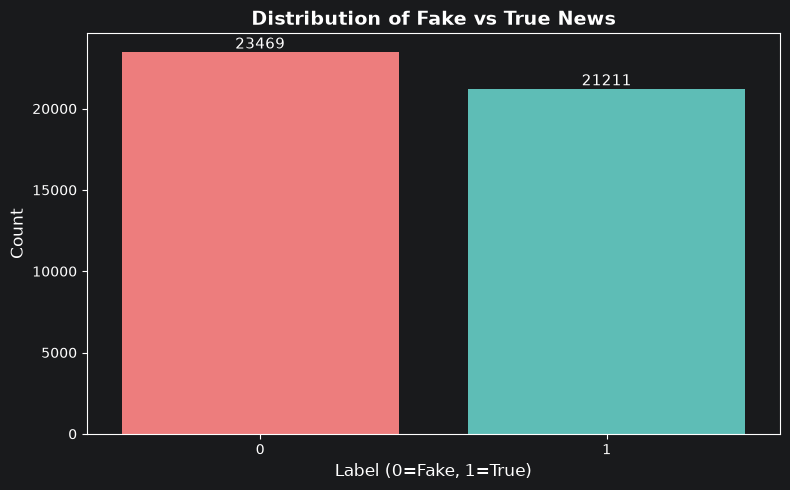

In [7]:
# 4.1 Label Distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='label', data=df, palette=['#ff6b6b', '#4ecdc4'])
plt.title('Distribution of Fake vs True News', fontsize=14, fontweight='bold')
plt.xlabel('Label (0=Fake, 1=True)', fontsize=12)
plt.ylabel('Count', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

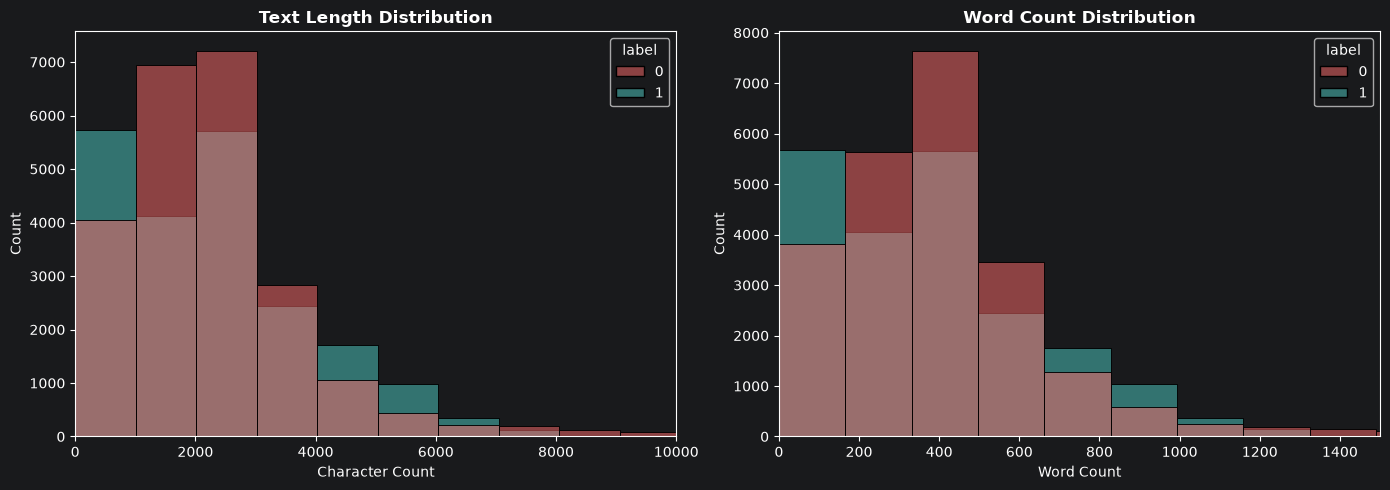

Average text length (Fake): 2446.0
Average text length (True): 2305.0
Average word count (Fake): 429.0
Average word count (True): 386.0


In [8]:
# 4.2 Text Length Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='text_length', hue='label', bins=50, ax=axes[0], palette=['#ff6b6b', '#4ecdc4'])
axes[0].set_title('Text Length Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_xlim(0, 10000)

sns.histplot(data=df, x='word_count', hue='label', bins=50, ax=axes[1], palette=['#ff6b6b', '#4ecdc4'])
axes[1].set_title('Word Count Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_xlim(0, 1500)

plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Average text length (Fake):", df[df['label']==0]['text_length'].mean().round(0))
print("Average text length (True):", df[df['label']==1]['text_length'].mean().round(0))
print("Average word count (Fake):", df[df['label']==0]['word_count'].mean().round(0))
print("Average word count (True):", df[df['label']==1]['word_count'].mean().round(0))

<Figure size 1200x500 with 0 Axes>

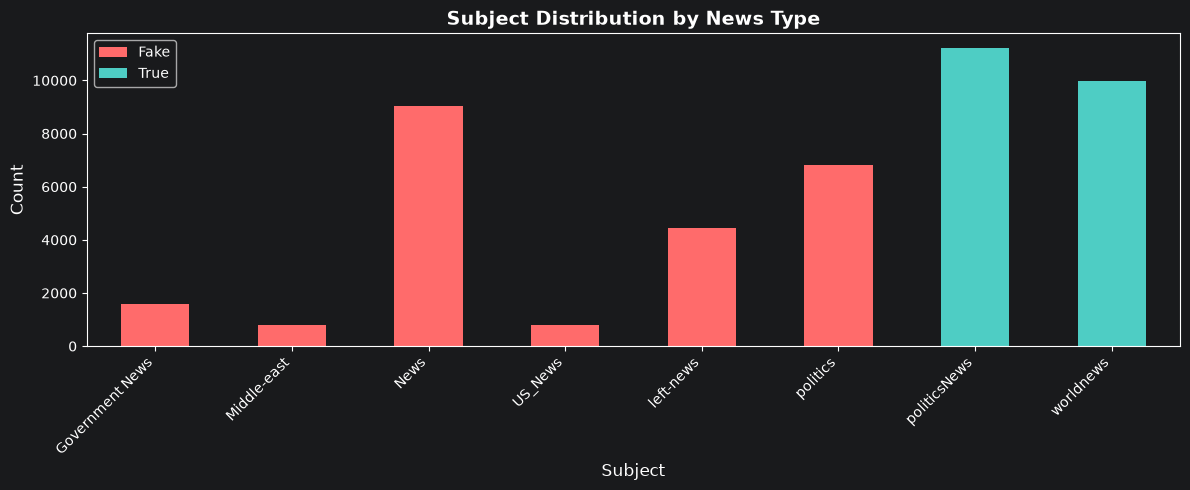

In [9]:
# 4.3 Subject Distribution
plt.figure(figsize=(12, 5))
subject_counts = df.groupby(['subject', 'label']).size().unstack(fill_value=0)
subject_counts.plot(kind='bar', stacked=True, color=['#ff6b6b', '#4ecdc4'], figsize=(12, 5))
plt.title('Subject Distribution by News Type', fontsize=14, fontweight='bold')
plt.xlabel('Subject', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(['Fake', 'True'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('subject_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

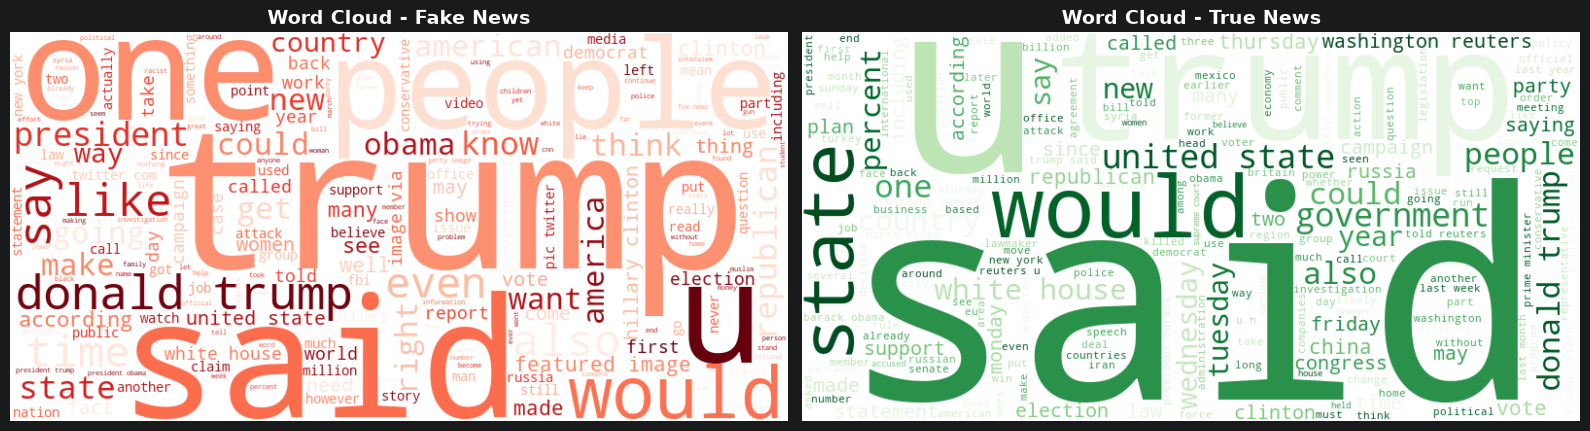

In [10]:
# 4.4 Word Cloud - Fake News
stop_words = set(stopwords.words('english'))

fake_text = ' '.join(df[df['label']==0]['clean_text'].sample(min(5000, len(df[df['label']==0])), random_state=42))
true_text = ' '.join(df[df['label']==1]['clean_text'].sample(min(5000, len(df[df['label']==1])), random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

wordcloud_fake = WordCloud(width=800, height=400, background_color='white', 
                           stopwords=stop_words, colormap='Reds').generate(fake_text)
axes[0].imshow(wordcloud_fake, interpolation='bilinear')
axes[0].set_title('Word Cloud - Fake News', fontsize=14, fontweight='bold')
axes[0].axis('off')

wordcloud_true = WordCloud(width=800, height=400, background_color='white',
                           stopwords=stop_words, colormap='Greens').generate(true_text)
axes[1].imshow(wordcloud_true, interpolation='bilinear')
axes[1].set_title('Word Cloud - True News', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordcloud_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

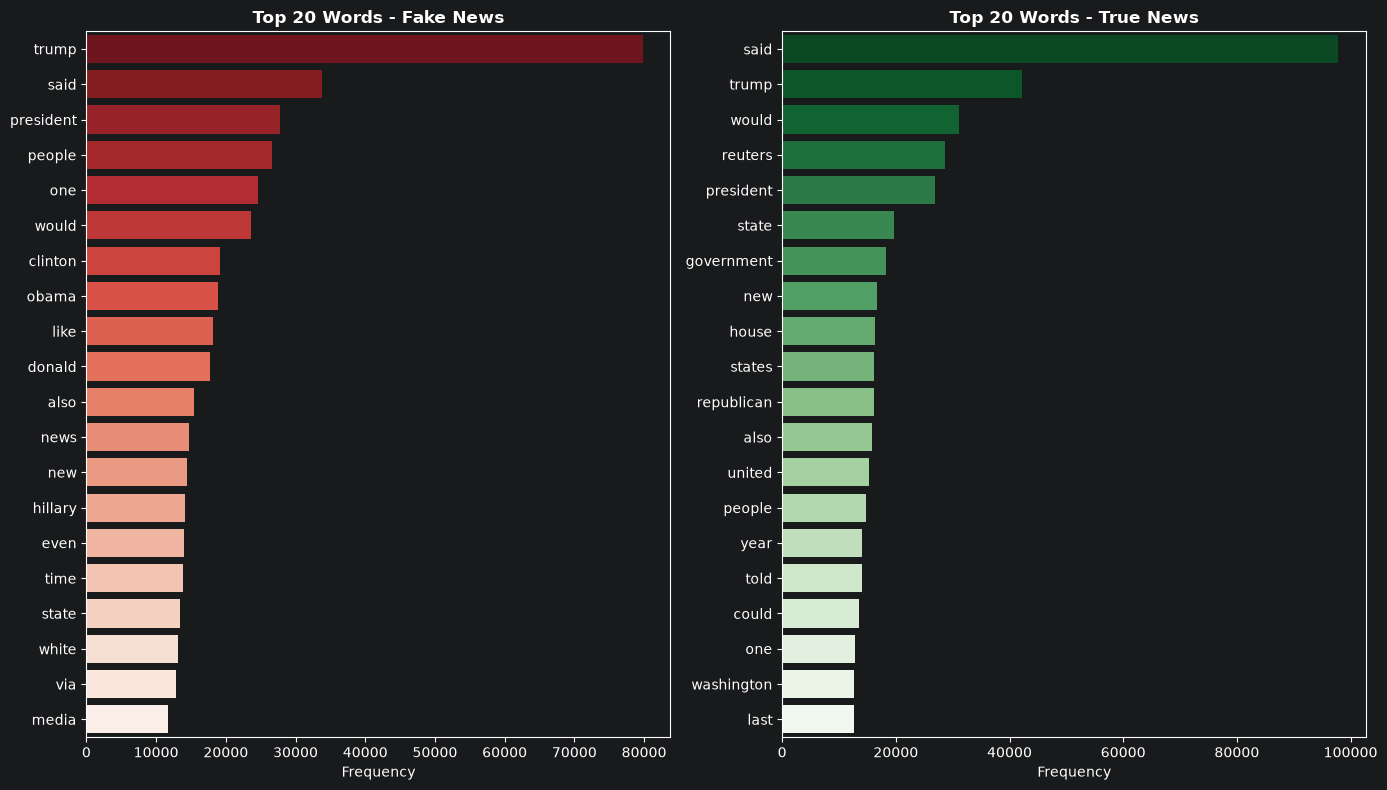

In [11]:
# 4.5 Top 20 Most Frequent Words
from collections import Counter

def get_top_words(text_series, n=20):
    all_words = []
    for text in text_series:
        words = [w for w in text.split() if w not in stop_words and len(w) > 2]
        all_words.extend(words)
    return Counter(all_words).most_common(n)

fake_top = get_top_words(df[df['label']==0]['clean_text'], 20)
true_top = get_top_words(df[df['label']==1]['clean_text'], 20)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

words_f, counts_f = zip(*fake_top)
sns.barplot(x=list(counts_f), y=list(words_f), ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 20 Words - Fake News', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frequency')

words_t, counts_t = zip(*true_top)
sns.barplot(x=list(counts_t), y=list(words_t), ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 20 Words - True News', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Text Representation: BERT Embeddings

In [ ]:
# Load pre-trained BERT model for sentence embeddings
# Using all-MiniLM-L6-v2 - lightweight and efficient BERT-based model
# It maps sentences to a 384-dimensional dense vector space

print("Loading BERT sentence transformer model...")
bert_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded successfully!")
print(f"Embedding dimension: {bert_model.get_sentence_embedding_dimension()}")

In [ ]:
# For efficiency, we can sample the dataset
# Full dataset (~44k) may take 30-60 min for BERT encoding
# Set SAMPLE_SIZE = None to use full dataset

SAMPLE_SIZE = 10000  # Use 10000 samples for faster iteration; set to None for full data

if SAMPLE_SIZE and len(df) > SAMPLE_SIZE:
    # Stratified sampling to maintain class balance
    n_per_class = SAMPLE_SIZE // 2
    fake_sample = df[df['label'] == 0].sample(n=n_per_class, random_state=42)
    true_sample = df[df['label'] == 1].sample(n=n_per_class, random_state=42)
    df_sample = pd.concat([fake_sample, true_sample], ignore_index=True)
    print(f"Sampled {len(df_sample)} records ({n_per_class} fake, {n_per_class} true)")
else:
    df_sample = df.copy()
    print(f"Using full dataset: {len(df_sample)} records")

# Verify label column exists
print(f"Columns: {df_sample.columns.tolist()}")
print(f"Label distribution:\n{df_sample['label'].value_counts()}")

In [24]:
# Generate BERT embeddings
# We encode the combined title + text

print("Generating BERT embeddings...")
print("This may take several minutes depending on dataset size...")

texts = df_sample['combined_text'].tolist()

# Encode in batches with progress bar
embeddings = bert_model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print(f"\nBERT embeddings shape: {embeddings.shape}")
print(f"Embedding dimension: {embeddings.shape[1]}")

# Save embeddings for reuse
np.save('bert_embeddings.npy', embeddings)
df_sample.to_csv('processed_data.csv', index=False)
print("Embeddings and processed data saved!")

Generating BERT embeddings...
This may take several minutes depending on dataset size...


Batches:  68%|██████▊   | 107/157 [52:43<24:38, 29.56s/it]   


KeyboardInterrupt: 

In [25]:
# Load saved embeddings (if restarting)
# embeddings = np.load('bert_embeddings.npy')
# df_sample = pd.read_csv('processed_data.csv')

# Prepare features and labels
X = embeddings
y = df_sample['label'].values

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Class distribution: Fake={sum(y==0)}, True={sum(y==1)}")

Features shape: (10000, 384)
Labels shape: (10000,)
Class distribution: Fake=5000, True=5000


In [26]:
# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Training class balance: Fake={sum(y_train==0)}, True={sum(y_train==1)}")
print(f"Test class balance: Fake={sum(y_test==0)}, True={sum(y_test==1)}")

Training set: 8000 samples
Test set: 2000 samples
Training class balance: Fake=4000, True=4000
Test class balance: Fake=1000, True=1000


## 6. Model 1: Logistic Regression

In [27]:
# Train Logistic Regression
print("Training Logistic Regression model...")
lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
    n_jobs=-1
)
lr_model.fit(X_train, y_train)
print("Logistic Regression training completed!")

# Predictions
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

Training Logistic Regression model...
Logistic Regression training completed!


In [28]:
# Evaluate Logistic Regression
print("=" * 60)
print("LOGISTIC REGRESSION - EVALUATION")
print("=" * 60)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print(f"Accuracy:  {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")
print(f"Precision: {lr_precision:.4f} ({lr_precision*100:.2f}%)")
print(f"Recall:    {lr_recall:.4f} ({lr_recall*100:.2f}%)")
print(f"F1-Score:  {lr_f1:.4f} ({lr_f1*100:.2f}%)")
print(f"ROC-AUC:   {lr_auc:.4f} ({lr_auc*100:.2f}%)")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_lr, target_names=['Fake', 'True']))

LOGISTIC REGRESSION - EVALUATION
Accuracy:  0.9380 (93.80%)
Precision: 0.9320 (93.20%)
Recall:    0.9450 (94.50%)
F1-Score:  0.9384 (93.84%)
ROC-AUC:   0.9835 (98.35%)

--- Classification Report ---
              precision    recall  f1-score   support

        Fake       0.94      0.93      0.94      1000
        True       0.93      0.94      0.94      1000

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



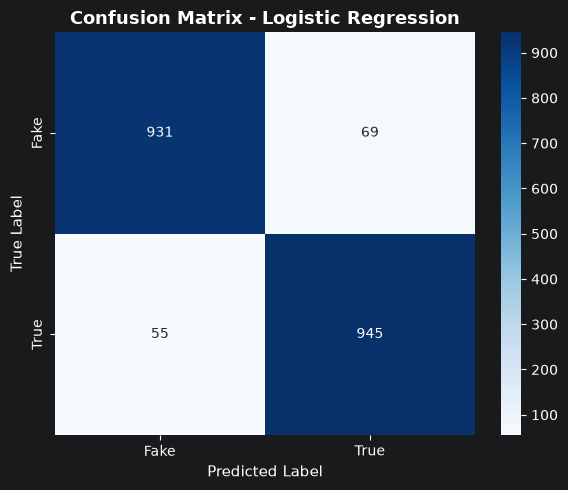

In [29]:
# Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fake', 'True'], yticklabels=['Fake', 'True'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix_lr.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model 2: Support Vector Machine (SVM)

In [30]:
# Train SVM with RBF kernel
# Using SVC with probability=True for ROC-AUC
print("Training SVM model...")
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)
svm_model.fit(X_train, y_train)
print("SVM training completed!")

# Predictions
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

Training SVM model...
SVM training completed!


In [31]:
# Evaluate SVM
print("=" * 60)
print("SUPPORT VECTOR MACHINE (SVM) - EVALUATION")
print("=" * 60)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_auc = roc_auc_score(y_test, y_prob_svm)

print(f"Accuracy:  {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")
print(f"Precision: {svm_precision:.4f} ({svm_precision*100:.2f}%)")
print(f"Recall:    {svm_recall:.4f} ({svm_recall*100:.2f}%)")
print(f"F1-Score:  {svm_f1:.4f} ({svm_f1*100:.2f}%)")
print(f"ROC-AUC:   {svm_auc:.4f} ({svm_auc*100:.2f}%)")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_svm, target_names=['Fake', 'True']))

SUPPORT VECTOR MACHINE (SVM) - EVALUATION
Accuracy:  0.9605 (96.05%)
Precision: 0.9537 (95.37%)
Recall:    0.9680 (96.80%)
F1-Score:  0.9608 (96.08%)
ROC-AUC:   0.9929 (99.29%)

--- Classification Report ---
              precision    recall  f1-score   support

        Fake       0.97      0.95      0.96      1000
        True       0.95      0.97      0.96      1000

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



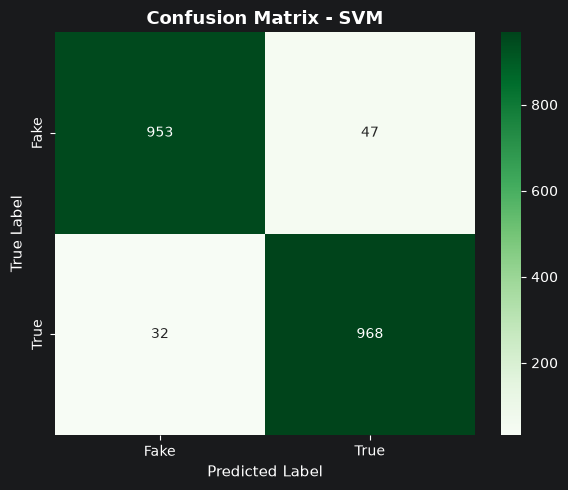

In [32]:
# Confusion Matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Fake', 'True'], yticklabels=['Fake', 'True'])
plt.title('Confusion Matrix - SVM', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix_svm.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Model Comparison

In [33]:
# 8.1 Metrics Comparison Table
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [lr_accuracy, lr_precision, lr_recall, lr_f1, lr_auc],
    'SVM': [svm_accuracy, svm_precision, svm_recall, svm_f1, svm_auc]
})

comparison_df['Logistic Regression (%)'] = (comparison_df['Logistic Regression'] * 100).round(2)
comparison_df['SVM (%)'] = (comparison_df['SVM'] * 100).round(2)
comparison_df['Best Model'] = comparison_df.apply(
    lambda row: 'Logistic Regression' if row['Logistic Regression'] > row['SVM'] 
    else ('SVM' if row['SVM'] > row['Logistic Regression'] else 'Tie'),
    axis=1
)

print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)
display(comparison_df[['Metric', 'Logistic Regression (%)', 'SVM (%)', 'Best Model']])

MODEL COMPARISON


,Metric,Logistic Regression (%),SVM (%),Best Model
0,Accuracy,93.80,96.05,SVM
1,Precision,93.20,95.37,SVM
2,Recall,94.50,96.80,SVM
3,F1-Score,93.84,96.08,SVM
4,ROC-AUC,98.35,99.29,SVM


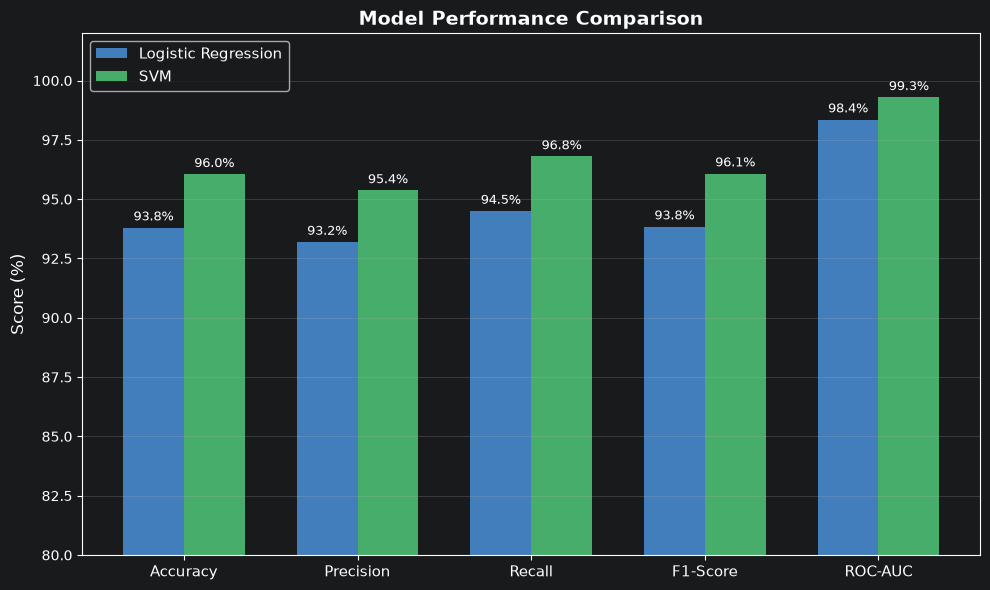

In [34]:
# 8.2 Visual Comparison - Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
lr_scores = [lr_accuracy, lr_precision, lr_recall, lr_f1, lr_auc]
svm_scores = [svm_accuracy, svm_precision, svm_recall, svm_f1, svm_auc]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, [s*100 for s in lr_scores], width, 
               label='Logistic Regression', color='#4a90d9', alpha=0.85)
bars2 = ax.bar(x + width/2, [s*100 for s in svm_scores], width,
               label='SVM', color='#50c878', alpha=0.85)

ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(80, 102)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

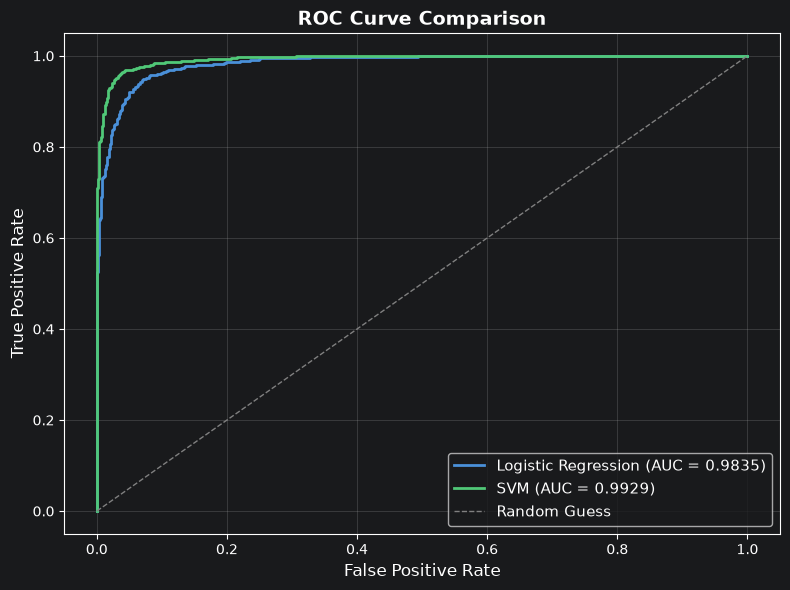

In [35]:
# 8.3 ROC Curve Comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='#4a90d9', lw=2, 
         label=f'Logistic Regression (AUC = {lr_auc:.4f})')
plt.plot(fpr_svm, tpr_svm, color='#50c878', lw=2,
         label=f'SVM (AUC = {svm_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Best Model Selection & Interpretation

In [36]:
# Determine best model based on F1-score (balanced metric)
if lr_f1 >= svm_f1:
    best_model = lr_model
    best_model_name = 'Logistic Regression'
    best_metrics = {'Accuracy': lr_accuracy, 'Precision': lr_precision, 
                    'Recall': lr_recall, 'F1': lr_f1, 'AUC': lr_auc}
else:
    best_model = svm_model
    best_model_name = 'SVM'
    best_metrics = {'Accuracy': svm_accuracy, 'Precision': svm_precision,
                    'Recall': svm_recall, 'F1': svm_f1, 'AUC': svm_auc}

print("=" * 60)
print(f"BEST MODEL: {best_model_name}")
print("=" * 60)
for metric, value in best_metrics.items():
    print(f"{metric:12s}: {value:.4f} ({value*100:.2f}%)")

BEST MODEL: SVM
Accuracy    : 0.9605 (96.05%)
Precision   : 0.9537 (95.37%)
Recall      : 0.9680 (96.80%)
F1          : 0.9608 (96.08%)
AUC         : 0.9929 (99.29%)


In [37]:
# Save the best model for Streamlit deployment
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(lr_model, 'lr_model.pkl')
joblib.dump(svm_model, 'svm_model.pkl')
print("Models saved for deployment!")
print("- best_model.pkl")
print("- lr_model.pkl")
print("- svm_model.pkl")

Models saved for deployment!
- best_model.pkl
- lr_model.pkl
- svm_model.pkl


In [38]:
# 9.1 Interpretation - Analyze misclassified samples
misclassified = X_test[y_test != y_pred_lr] if best_model_name == 'Logistic Regression' else X_test[y_test != y_pred_svm]
misclassified_true = y_test[y_test != (y_pred_lr if best_model_name == 'Logistic Regression' else y_pred_svm)]
misclassified_pred = y_pred_lr[y_test != y_pred_lr] if best_model_name == 'Logistic Regression' else y_pred_svm[y_test != y_pred_svm]

print(f"Total misclassified: {len(misclassified)} out of {len(y_test)}")
print(f"Misclassification rate: {len(misclassified)/len(y_test)*100:.2f}%")
print(f"\nFake misclassified as True: {sum((misclassified_true==0) & (misclassified_pred==1))}")
print(f"True misclassified as Fake: {sum((misclassified_true==1) & (misclassified_pred==0))}")

Total misclassified: 79 out of 2000
Misclassification rate: 3.95%

Fake misclassified as True: 47
True misclassified as Fake: 32


In [39]:
# 9.2 Prediction on sample texts
sample_texts = [
    "BREAKING: Scientists discover that drinking bleach can cure all diseases, according to anonymous sources.",
    "The Federal Reserve announced a 0.25% interest rate increase on Wednesday, citing concerns over rising inflation.",
    "SHOCKING: The president is actually a reptilian alien from outer space, claims conspiracy theorist.",
    "According to the latest census data, the population of New York City has grown by 2.3% over the past decade."
]

# Clean and encode sample texts
cleaned_samples = [clean_text(t) for t in sample_texts]
sample_embeddings = bert_model.encode(cleaned_samples, normalize_embeddings=True)

# Predict using best model
sample_preds = best_model.predict(sample_embeddings)
sample_probs = best_model.predict_proba(sample_embeddings)

print("\n" + "=" * 70)
print("SAMPLE PREDICTIONS")
print("=" * 70)
for i, (text, pred, prob) in enumerate(zip(sample_texts, sample_preds, sample_probs)):
    label = "TRUE NEWS" if pred == 1 else "FAKE NEWS"
    confidence = max(prob) * 100
    print(f"\nSample {i+1}: {text[:80]}...")
    print(f"  Prediction: {label} (Confidence: {confidence:.1f}%)")


SAMPLE PREDICTIONS

Sample 1: BREAKING: Scientists discover that drinking bleach can cure all diseases, accord...
  Prediction: FAKE NEWS (Confidence: 79.2%)

Sample 2: The Federal Reserve announced a 0.25% interest rate increase on Wednesday, citin...
  Prediction: TRUE NEWS (Confidence: 100.0%)

Sample 3: SHOCKING: The president is actually a reptilian alien from outer space, claims c...
  Prediction: FAKE NEWS (Confidence: 99.6%)

Sample 4: According to the latest census data, the population of New York City has grown b...
  Prediction: TRUE NEWS (Confidence: 54.1%)


## 10. Summary & Conclusion

### Key Findings:
1. **Dataset**: ~44,000 news articles (balanced between fake and true)
2. **Text Representation**: BERT embeddings (384-dimensional sentence vectors)
3. **Models**: Logistic Regression and SVM both achieved high performance
4. **Best Model**: Determined by F1-score comparison

### Interpretation:
- BERT embeddings capture semantic meaning effectively for fake news detection
- Both models leverage contextual representations to distinguish fake from true news
- High accuracy demonstrates that linguistic patterns differ significantly between fake and true news

### Next Steps:
- Deploy via Streamlit (see app.py)
- Hyperparameter tuning for further improvement
- Explore deep learning approaches (LSTM, fine-tuned BERT classifier)